<a href="https://colab.research.google.com/github/Fatma3598/elsewedy-demand-forecasting/blob/main/Notebooks/ElSewedy_Data_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loading dataset...
Loaded 612 records
Date range: 2022-01-01 to 2024-12-01

EXPLORATORY DATA ANALYSIS

1. DATASET OVERVIEW:
----------------------------------------------------------------------
Total Records: 612
Unique Materials: 17
Unique Suppliers: 8
Date Range: 1065 days

2. DEMAND STATISTICS BY MATERIAL TYPE:
----------------------------------------------------------------------
                      Mean  Std Dev    Min    Max    Total
Material_Type                                             
XLPE                 46.51    14.17  23.58  92.78  5023.57
PVC                  35.40     4.19  27.21  45.50  2548.83
Semiconductor        34.03     9.16  19.25  62.84  2450.21
PE                   25.97     4.50  17.97  39.69  1869.94
GSW                  20.62     3.58  14.53  29.26  1484.56
Water Blocking Tape  25.74     4.85  16.31  36.58   926.79
GST                  20.83     2.31  16.26  26.96   749.75
LSF                  17.99     2.58  13.05  22.75   647.80
Copper Screen        1

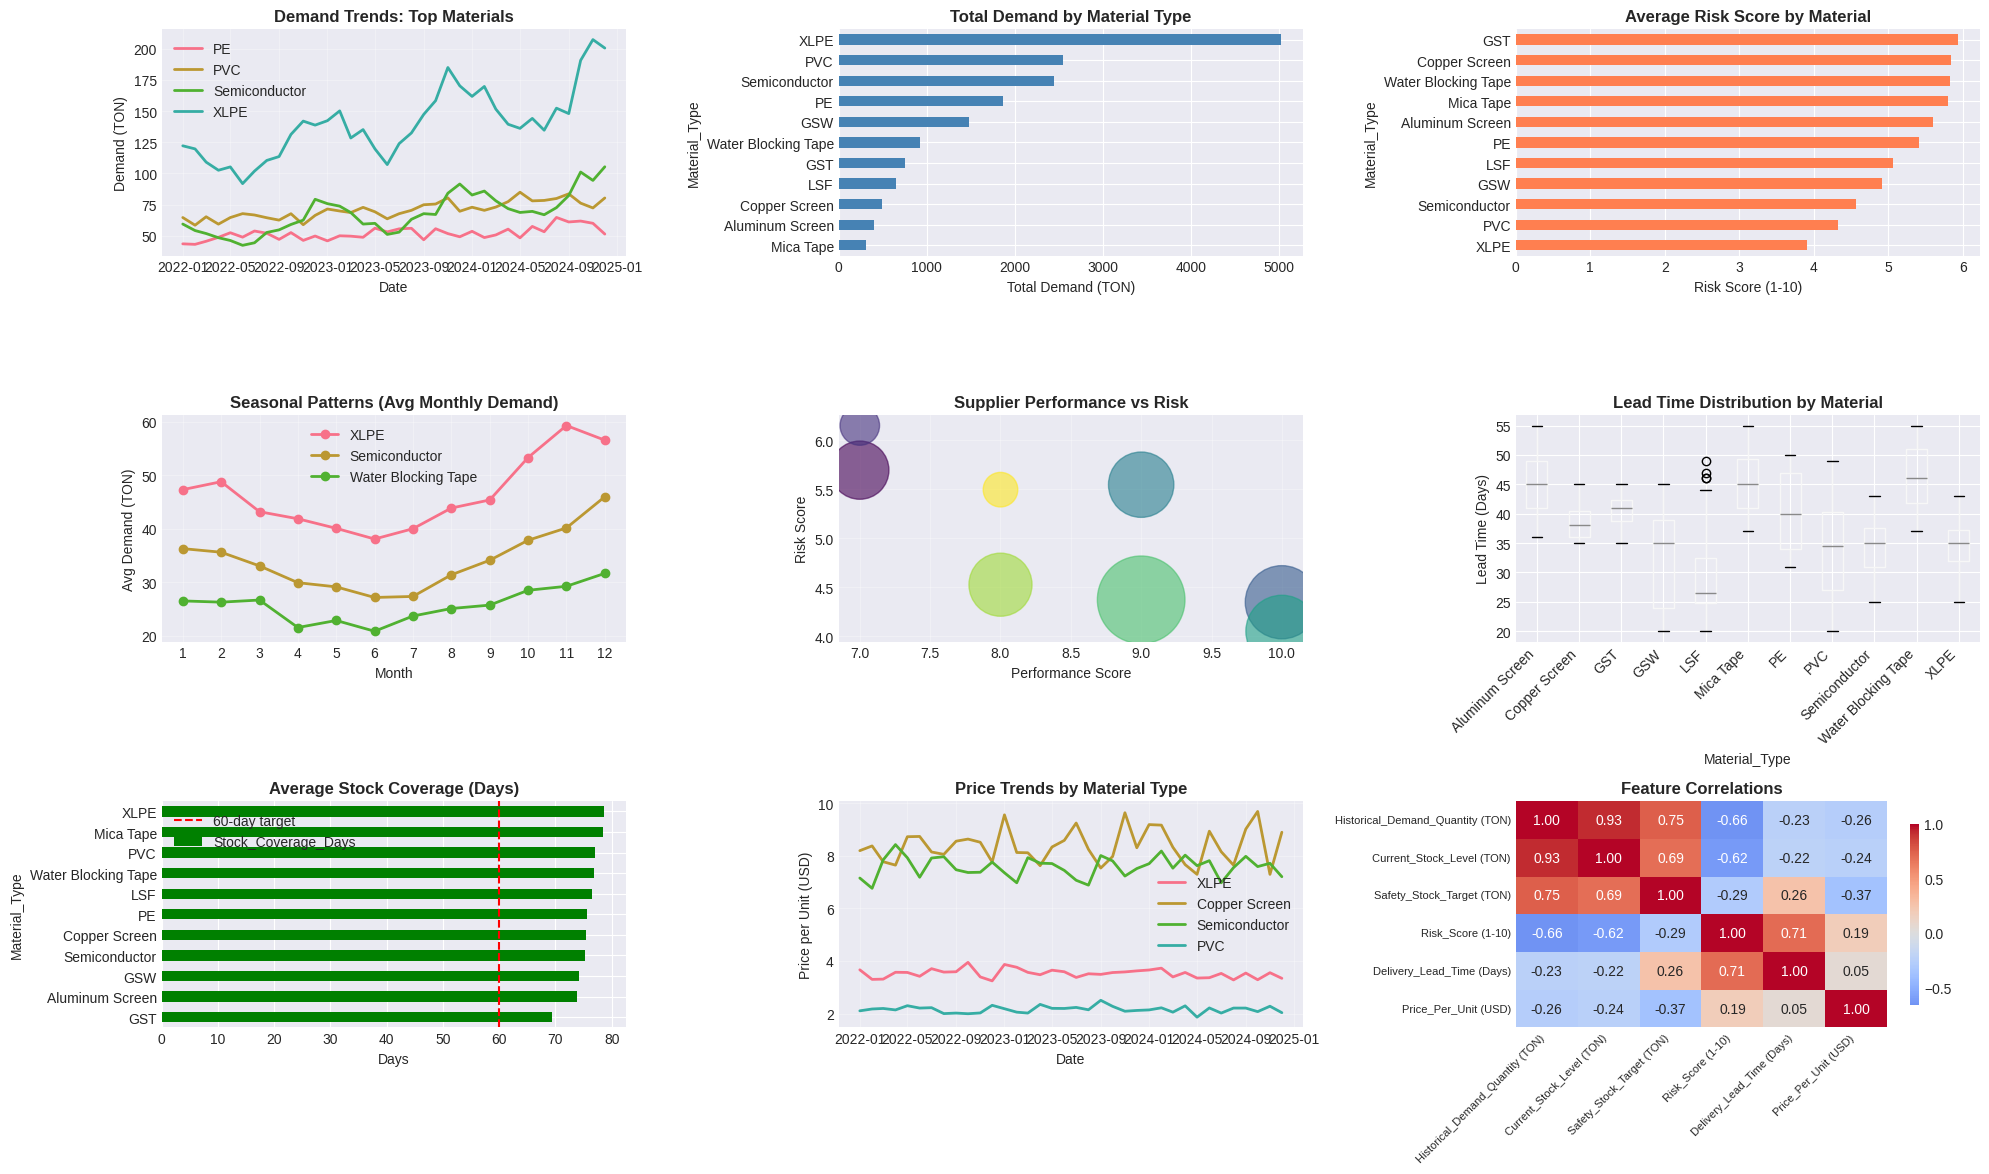

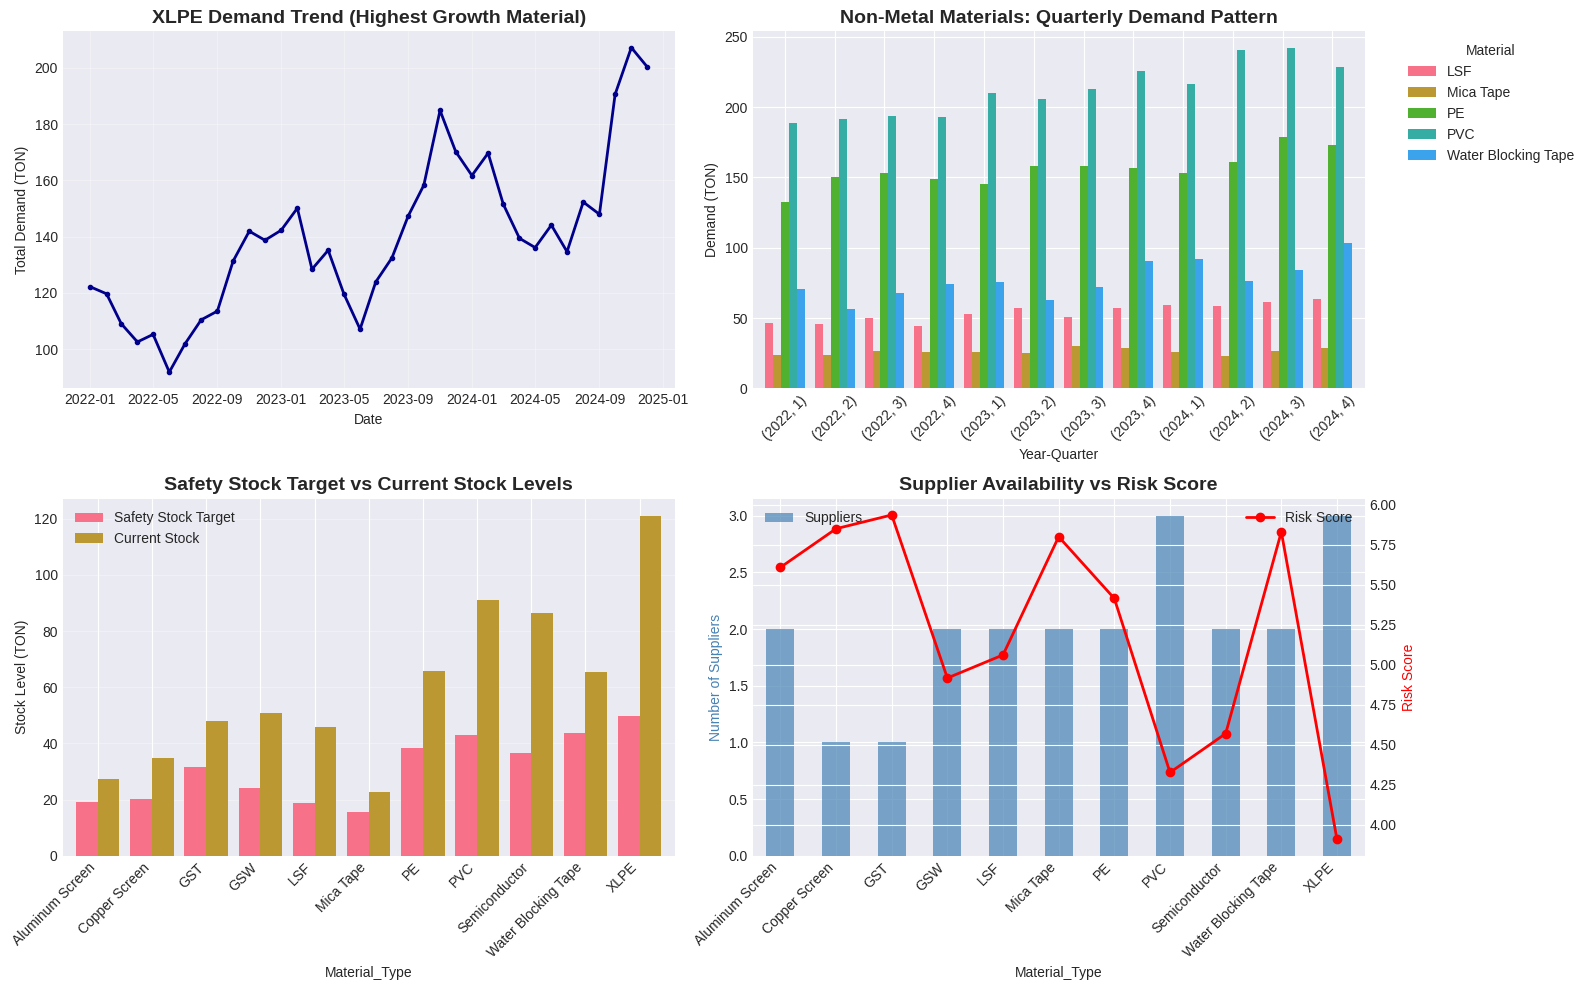


ANALYSIS COMPLETE!

Generated Files:
   1. elsewedy_data_analysis.png (9 comprehensive charts)
   2. elsewedy_deep_analysis.png (4 focused insights)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# ============================================================================
# LOAD DATA
# ============================================================================

print("Loading dataset...")
df = pd.read_csv('elsewedy_materials_dataset.csv')
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Quarter'] = df['Date'].dt.quarter

print(f"Loaded {len(df):,} records")
print(f"Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")

# ============================================================================
# EXPLORATORY DATA ANALYSIS
# ============================================================================

print("\n" + "="*70)
print("EXPLORATORY DATA ANALYSIS")
print("="*70)

# 1. Basic Statistics
print("\n1. DATASET OVERVIEW:")
print("-" * 70)
print(f"Total Records: {len(df):,}")
print(f"Unique Materials: {df['Item_Code'].nunique()}")
print(f"Unique Suppliers: {df['Supplier'].nunique()}")
print(f"Date Range: {(df['Date'].max() - df['Date'].min()).days} days")

# 2. Demand Statistics by Material Type
print("\n2. DEMAND STATISTICS BY MATERIAL TYPE:")
print("-" * 70)
demand_stats = df.groupby('Material_Type').agg({
    'Historical_Demand_Quantity (TON)': ['mean', 'std', 'min', 'max', 'sum']
}).round(2)
demand_stats.columns = ['Mean', 'Std Dev', 'Min', 'Max', 'Total']
demand_stats = demand_stats.sort_values('Total', ascending=False)
print(demand_stats.to_string())

# 3. Risk Analysis
print("\n3. RISK ANALYSIS BY MATERIAL:")
print("-" * 70)
risk_analysis = df.groupby('Material_Type').agg({
    'Risk_Score (1-10)': 'mean',
    'Number_Of_Alternative_Suppliers': 'mean',
    'Delivery_Lead_Time (Days)': 'mean',
    'Supplier_Performance_Score (1-10)': 'mean'
}).round(2)
risk_analysis.columns = ['Avg Risk', 'Avg Suppliers', 'Avg Lead Time', 'Avg Performance']
risk_analysis = risk_analysis.sort_values('Avg Risk', ascending=False)
print(risk_analysis.to_string())

# 4. Supplier Performance
print("\n4. SUPPLIER PERFORMANCE:")
print("-" * 70)
supplier_stats = df.groupby('Supplier').agg({
    'Historical_Demand_Quantity (TON)': 'sum',
    'Supplier_Performance_Score (1-10)': 'first',
    'Risk_Score (1-10)': 'mean',
    'Item_Code': 'count'
}).round(2)
supplier_stats.columns = ['Total Volume', 'Performance', 'Avg Risk', 'Orders']
supplier_stats = supplier_stats.sort_values('Total Volume', ascending=False)
print(supplier_stats.to_string())

# 5. Growth Trends
print("\n5. YEAR-OVER-YEAR GROWTH:")
print("-" * 70)
yearly_demand = df.groupby(['Year', 'Material_Type'])['Historical_Demand_Quantity (TON)'].sum().unstack()
growth_2023 = ((yearly_demand.loc[2023] - yearly_demand.loc[2022]) / yearly_demand.loc[2022] * 100).round(2)
growth_2024 = ((yearly_demand.loc[2024] - yearly_demand.loc[2023]) / yearly_demand.loc[2023] * 100).round(2)
growth_df = pd.DataFrame({
    '2023 Growth (%)': growth_2023,
    '2024 Growth (%)': growth_2024
}).sort_values('2024 Growth (%)', ascending=False)
print(growth_df.to_string())

# 6. Inventory Health
print("\n6. INVENTORY HEALTH METRICS:")
print("-" * 70)
df['Stock_Coverage_Days'] = (df['Current_Stock_Level (TON)'] / df['Historical_Demand_Quantity (TON)']) * 30
df['Safety_Stock_Ratio'] = df['Safety_Stock_Target (TON)'] / df['Current_Stock_Level (TON)']
df['Stockout_Risk'] = (df['Current_Stock_Level (TON)'] < df['Safety_Stock_Target (TON)']).astype(int)

inventory_health = df.groupby('Material_Type').agg({
    'Stock_Coverage_Days': 'mean',
    'Safety_Stock_Ratio': 'mean',
    'Stockout_Risk': 'mean'
}).round(2)
inventory_health.columns = ['Avg Coverage (Days)', 'Safety/Current Ratio', 'Stockout Risk (%)']
inventory_health['Stockout Risk (%)'] = (inventory_health['Stockout Risk (%)'] * 100).round(1)
print(inventory_health.to_string())

# ============================================================================
# KEY INSIGHTS
# ============================================================================

print("\n" + "="*70)
print("KEY INSIGHTS")
print("="*70)

# Top 3 materials by demand
top_materials = df.groupby('Material_Type')['Historical_Demand_Quantity (TON)'].sum().nlargest(3)
print("\n Top 3 Materials by Total Demand:")
for i, (mat, vol) in enumerate(top_materials.items(), 1):
    print(f"   {i}. {mat}: {vol:,.2f} TON")

# Highest risk materials
high_risk = df.groupby('Material_Type')['Risk_Score (1-10)'].mean().nlargest(3)
print("\nHighest Risk Materials:")
for i, (mat, risk) in enumerate(high_risk.items(), 1):
    print(f"   {i}. {mat}: Risk Score {risk:.2f}")

# Materials with stockout risk
stockout_materials = df[df['Stockout_Risk'] == 1].groupby('Material_Type').size().nlargest(3)
print("\nMaterials with Most Stockout Events:")
for i, (mat, count) in enumerate(stockout_materials.items(), 1):
    print(f"   {i}. {mat}: {count} instances")

# ============================================================================
# VISUALIZATIONS
# ============================================================================

print("\nGenerating visualizations...")

fig = plt.figure(figsize=(20, 12))

# 1. Demand Trends Over Time by Material Type
ax1 = plt.subplot(3, 3, 1)
monthly_demand = df.groupby(['Date', 'Material_Type'])['Historical_Demand_Quantity (TON)'].sum().unstack()
for col in monthly_demand.columns:
    if col in ['XLPE', 'Semiconductor', 'PVC', 'PE']:  # Top materials
        plt.plot(monthly_demand.index, monthly_demand[col], label=col, linewidth=2)
plt.title('Demand Trends: Top Materials', fontsize=12, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Demand (TON)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)

# 2. Total Demand by Material Type (Bar Chart)
ax2 = plt.subplot(3, 3, 2)
total_demand = df.groupby('Material_Type')['Historical_Demand_Quantity (TON)'].sum().sort_values(ascending=True)
total_demand.plot(kind='barh', ax=ax2, color='steelblue')
plt.title('Total Demand by Material Type', fontsize=12, fontweight='bold')
plt.xlabel('Total Demand (TON)')
plt.tight_layout()

# 3. Risk Score Distribution
ax3 = plt.subplot(3, 3, 3)
df.groupby('Material_Type')['Risk_Score (1-10)'].mean().sort_values().plot(
    kind='barh', ax=ax3, color='coral'
)
plt.title('Average Risk Score by Material', fontsize=12, fontweight='bold')
plt.xlabel('Risk Score (1-10)')
plt.tight_layout()

# 4. Seasonality Pattern
ax4 = plt.subplot(3, 3, 4)
seasonal_demand = df.groupby(['Month', 'Material_Type'])['Historical_Demand_Quantity (TON)'].mean().unstack()
for col in ['XLPE', 'Semiconductor', 'Water Blocking Tape']:
    if col in seasonal_demand.columns:
        plt.plot(seasonal_demand.index, seasonal_demand[col], marker='o', label=col, linewidth=2)
plt.title('Seasonal Patterns (Avg Monthly Demand)', fontsize=12, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Avg Demand (TON)')
plt.legend()
plt.xticks(range(1, 13))
plt.grid(True, alpha=0.3)

# 5. Supplier Performance vs Risk
ax5 = plt.subplot(3, 3, 5)
supplier_metrics = df.groupby('Supplier').agg({
    'Supplier_Performance_Score (1-10)': 'first',
    'Risk_Score (1-10)': 'mean',
    'Historical_Demand_Quantity (TON)': 'sum'
})
scatter = plt.scatter(
    supplier_metrics['Supplier_Performance_Score (1-10)'],
    supplier_metrics['Risk_Score (1-10)'],
    s=supplier_metrics['Historical_Demand_Quantity (TON)'],
    alpha=0.6,
    c=range(len(supplier_metrics)),
    cmap='viridis'
)
plt.title('Supplier Performance vs Risk', fontsize=12, fontweight='bold')
plt.xlabel('Performance Score')
plt.ylabel('Risk Score')
plt.grid(True, alpha=0.3)

# 6. Lead Time Distribution
ax6 = plt.subplot(3, 3, 6)
df.boxplot(column='Delivery_Lead_Time (Days)', by='Material_Type', ax=ax6, rot=90)
plt.title('Lead Time Distribution by Material', fontsize=12, fontweight='bold')
plt.suptitle('')  # Remove default title
plt.ylabel('Lead Time (Days)')
plt.xticks(rotation=45, ha='right')

# 7. Stock Coverage Analysis
ax7 = plt.subplot(3, 3, 7)
coverage = df.groupby('Material_Type')['Stock_Coverage_Days'].mean().sort_values()
coverage.plot(kind='barh', ax=ax7, color='green')
plt.title('Average Stock Coverage (Days)', fontsize=12, fontweight='bold')
plt.xlabel('Days')
plt.axvline(60, color='red', linestyle='--', label='60-day target')
plt.legend()

# 8. Price Trends
ax8 = plt.subplot(3, 3, 8)
price_trends = df.groupby(['Date', 'Material_Type'])['Price_Per_Unit (USD)'].mean().unstack()
for col in ['XLPE', 'Copper Screen', 'Semiconductor', 'PVC']:
    if col in price_trends.columns:
        plt.plot(price_trends.index, price_trends[col], label=col, linewidth=2)
plt.title('Price Trends by Material Type', fontsize=12, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Price per Unit (USD)')
plt.legend()
plt.grid(True, alpha=0.3)

# 9. Correlation Heatmap
ax9 = plt.subplot(3, 3, 9)
corr_cols = ['Historical_Demand_Quantity (TON)', 'Current_Stock_Level (TON)',
             'Safety_Stock_Target (TON)', 'Risk_Score (1-10)',
             'Delivery_Lead_Time (Days)', 'Price_Per_Unit (USD)']
corr_matrix = df[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax9, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlations', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)

plt.tight_layout()
plt.savefig('elsewedy_data_analysis.png', dpi=300, bbox_inches='tight')
print("Visualizations saved to: elsewedy_data_analysis.png")

# Additional focused visualizations
fig2 = plt.figure(figsize=(16, 10))

# XLPE Deep Dive
ax1 = plt.subplot(2, 2, 1)
xlpe_data = df[df['Material_Type'] == 'XLPE']
xlpe_monthly = xlpe_data.groupby('Date')['Historical_Demand_Quantity (TON)'].sum()
plt.plot(xlpe_monthly.index, xlpe_monthly.values, linewidth=2, color='darkblue', marker='o', markersize=3)
plt.title('XLPE Demand Trend (Highest Growth Material)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Total Demand (TON)')
plt.grid(True, alpha=0.3)

# Quarterly ordering pattern for non-metals
ax2 = plt.subplot(2, 2, 2)
non_metal_materials = ['PVC', 'PE', 'LSF', 'Water Blocking Tape', 'Mica Tape']
quarterly_data = df[df['Material_Type'].isin(non_metal_materials)].groupby(
    ['Year', 'Quarter', 'Material_Type']
)['Historical_Demand_Quantity (TON)'].sum().unstack()
quarterly_data.plot(kind='bar', ax=ax2, width=0.8)
plt.title('Non-Metal Materials: Quarterly Demand Pattern', fontsize=14, fontweight='bold')
plt.xlabel('Year-Quarter')
plt.ylabel('Demand (TON)')
plt.xticks(rotation=45)
plt.legend(title='Material', bbox_to_anchor=(1.05, 1), loc='upper left')

# Safety Stock vs Actual Stock
ax3 = plt.subplot(2, 2, 3)
stock_comparison = df.groupby('Material_Type').agg({
    'Safety_Stock_Target (TON)': 'mean',
    'Current_Stock_Level (TON)': 'mean'
})
stock_comparison.plot(kind='bar', ax=ax3, width=0.8)
plt.title('Safety Stock Target vs Current Stock Levels', fontsize=14, fontweight='bold')
plt.ylabel('Stock Level (TON)')
plt.xticks(rotation=45, ha='right')
plt.legend(['Safety Stock Target', 'Current Stock'])
plt.grid(True, alpha=0.3, axis='y')

# Number of alternative suppliers vs Risk
ax4 = plt.subplot(2, 2, 4)
supplier_risk = df.groupby('Material_Type').agg({
    'Number_Of_Alternative_Suppliers': 'mean',
    'Risk_Score (1-10)': 'mean'
})
ax4_2 = ax4.twinx()
supplier_risk['Number_Of_Alternative_Suppliers'].plot(kind='bar', ax=ax4, color='steelblue', alpha=0.7, label='Suppliers')
supplier_risk['Risk_Score (1-10)'].plot(kind='line', ax=ax4_2, color='red', marker='o', linewidth=2, label='Risk Score')
plt.title('Supplier Availability vs Risk Score', fontsize=14, fontweight='bold')
ax4.set_ylabel('Number of Suppliers', color='steelblue')
ax4_2.set_ylabel('Risk Score', color='red')
ax4.set_xticklabels(ax4.get_xticklabels(), rotation=45, ha='right')
ax4.legend(loc='upper left')
ax4_2.legend(loc='upper right')

plt.tight_layout()
plt.savefig('elsewedy_deep_analysis.png', dpi=300, bbox_inches='tight')
print("Deep analysis saved to: elsewedy_deep_analysis.png")

plt.show()

print("\n" + "="*70)
print("ANALYSIS COMPLETE!")
print("="*70)
print("\nGenerated Files:")
print("   1. elsewedy_data_analysis.png (9 comprehensive charts)")
print("   2. elsewedy_deep_analysis.png (4 focused insights)")

# **Expanded Dataset**

Loading dataset...
Loaded 2,736 records
Date range: 2019-01-01 to 2024-12-01

EXPLORATORY DATA ANALYSIS

1. DATASET OVERVIEW:
----------------------------------------------------------------------
Total Records: 2,736
Unique Materials: 38
Unique Suppliers: 15
Date Range: 2161 days

2. DEMAND STATISTICS BY MATERIAL TYPE:
----------------------------------------------------------------------
                      Mean  Std Dev    Min     Max     Total
Material_Type                                               
XLPE                 64.28    33.53  16.53  220.33  27770.70
Semiconductor        41.37    16.70  12.17  104.40  11914.87
PVC                  35.70     8.45  18.66   62.40  10282.80
PE                   26.64     7.73  13.13   51.85   7672.79
Water Blocking Tape  31.22    11.50  12.29   77.77   6744.43
GSW                  22.26     6.50  11.46   43.43   4809.24
LSF                  17.72     5.88   7.43   37.35   3827.04
GST                  24.95     6.63  13.74   41.78   3593.

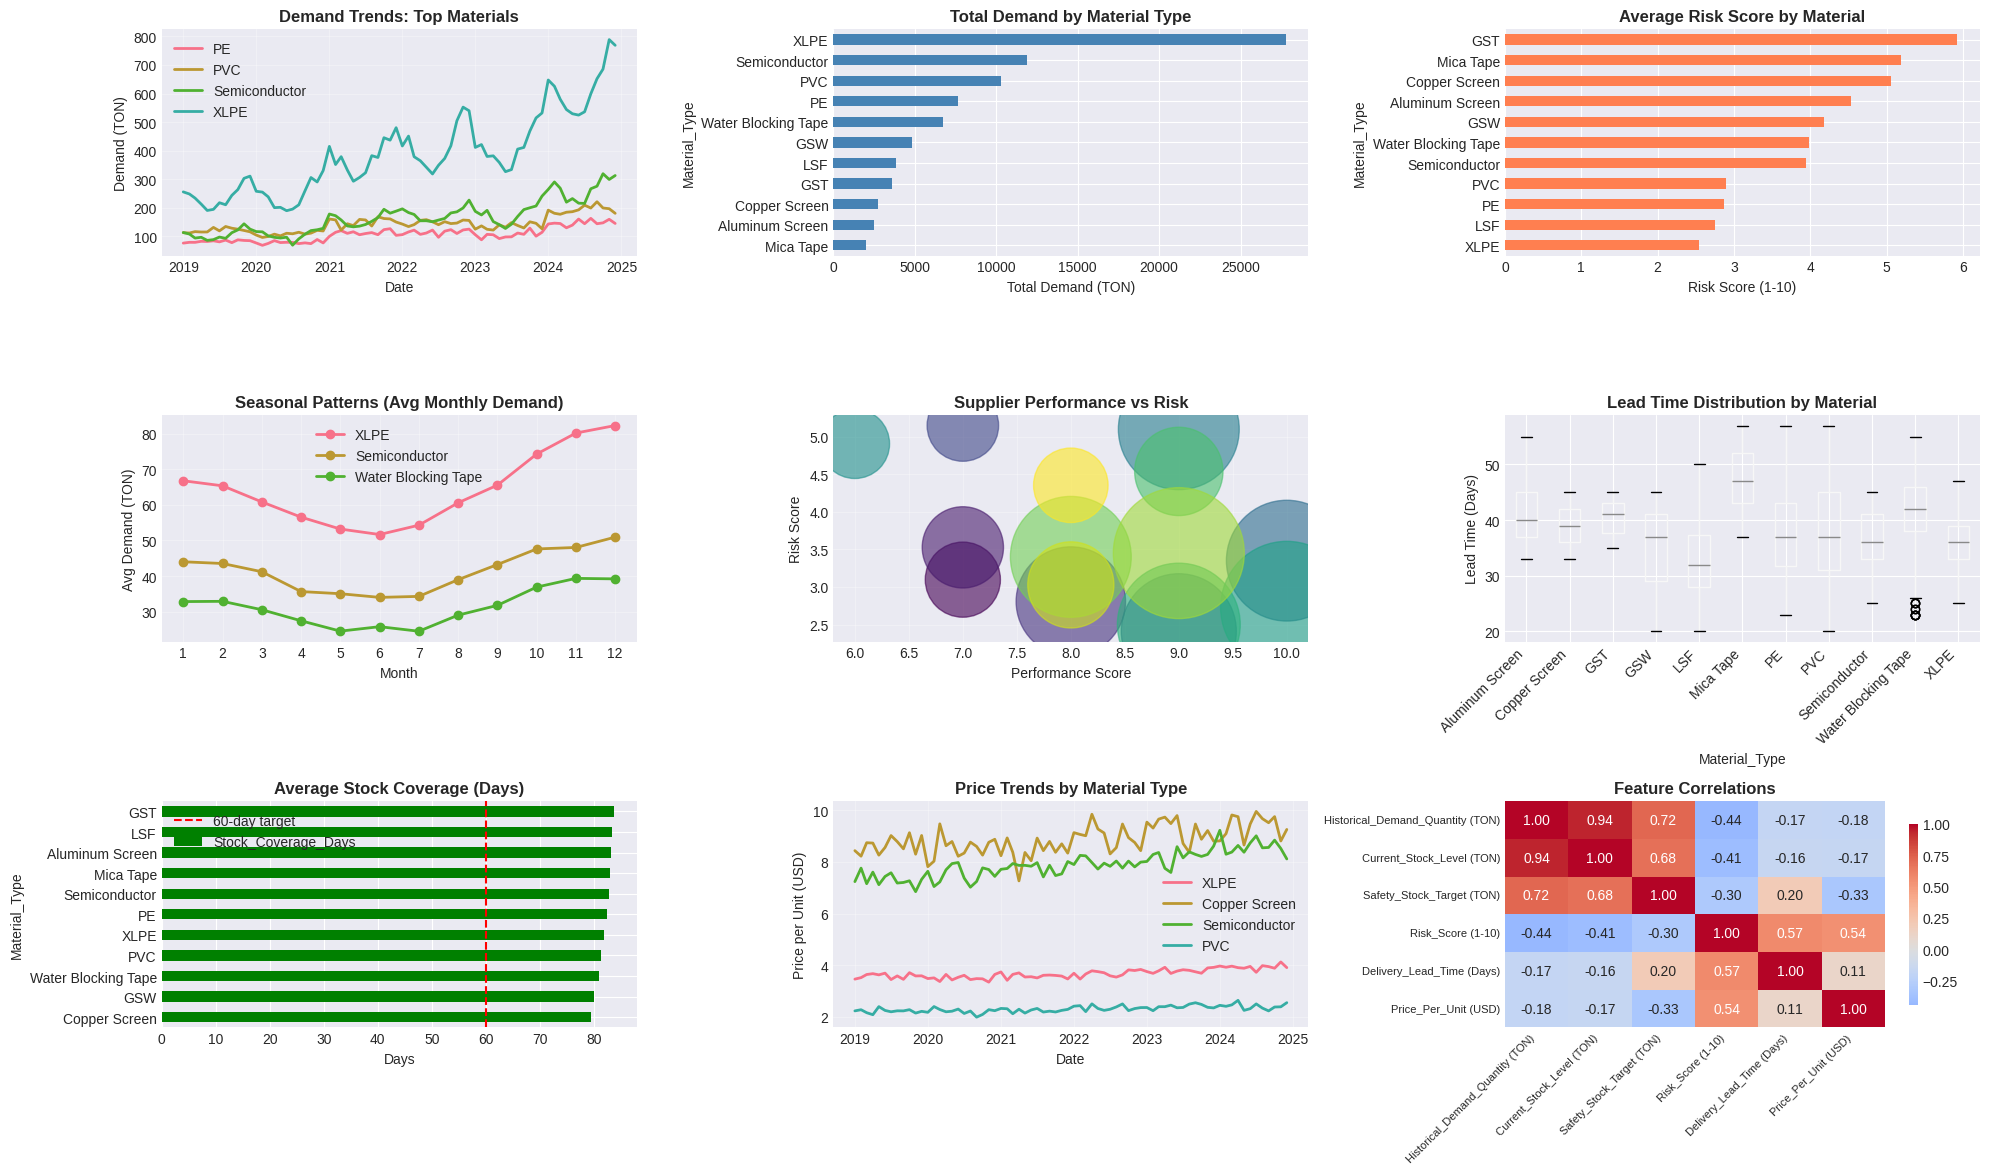

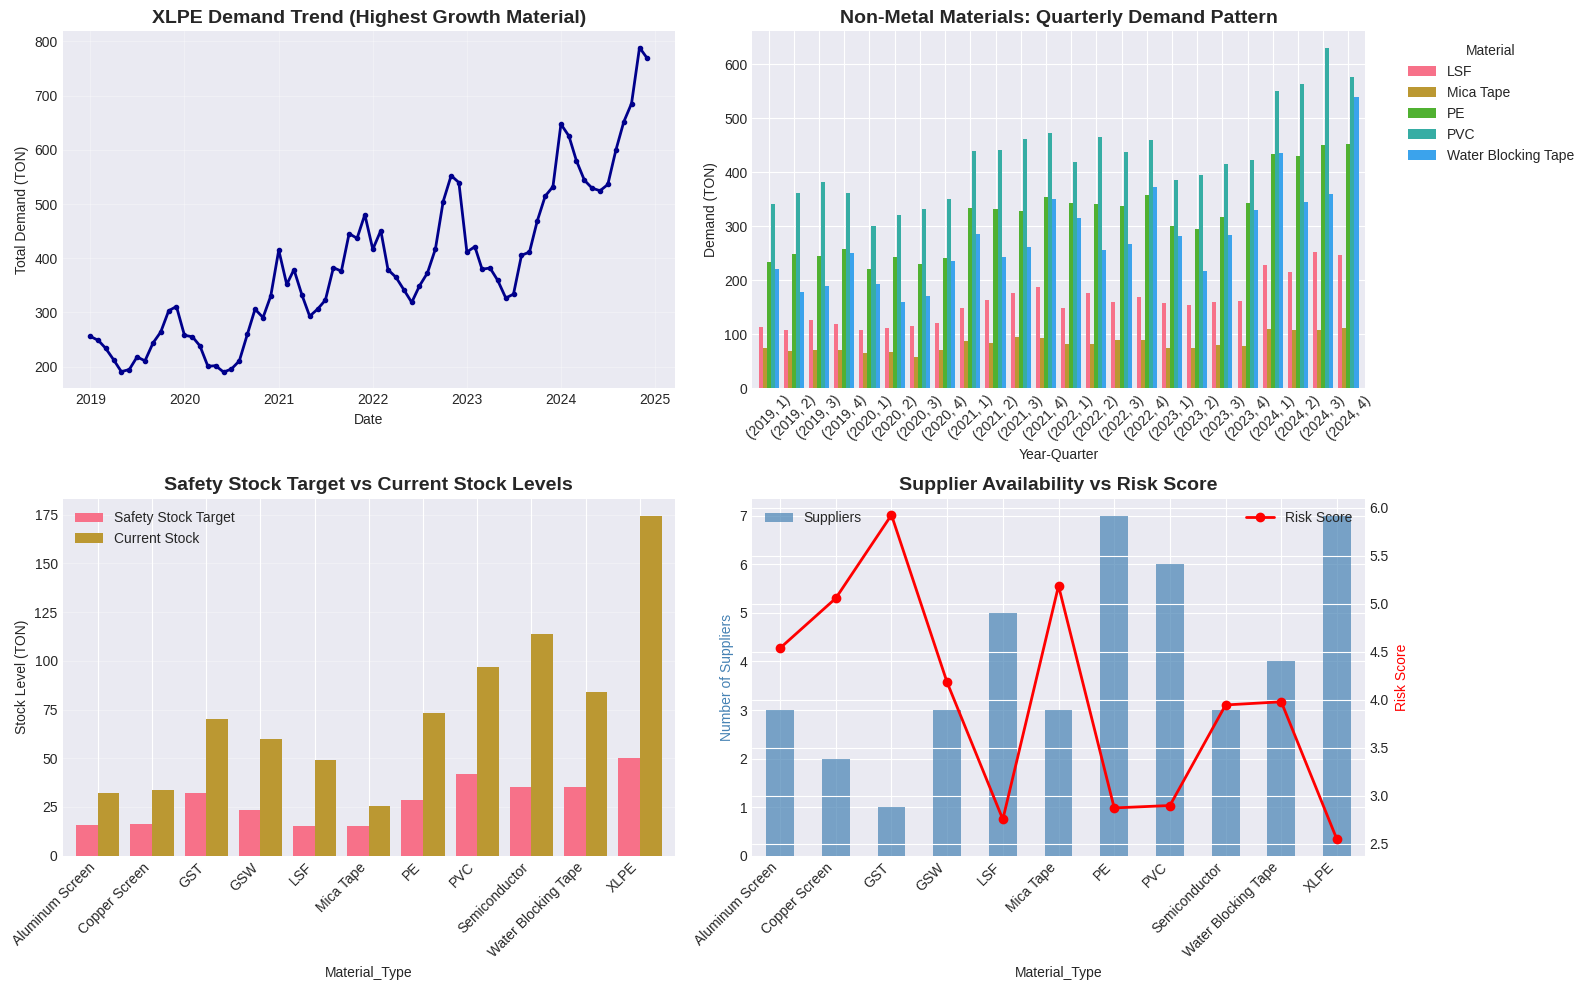


ANALYSIS COMPLETE!

Generated Files:
   1. elsewedy_data_analysis.png (9 comprehensive charts)
   2. elsewedy_deep_analysis.png (4 focused insights)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# ============================================================================
# LOAD DATA
# ============================================================================

print("Loading dataset...")
df = pd.read_csv('elsewedy_materials_dataset_expanded.csv')
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Quarter'] = df['Date'].dt.quarter

print(f"Loaded {len(df):,} records")
print(f"Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")

# ============================================================================
# EXPLORATORY DATA ANALYSIS
# ============================================================================

print("\n" + "="*70)
print("EXPLORATORY DATA ANALYSIS")
print("="*70)

# 1. Basic Statistics
print("\n1. DATASET OVERVIEW:")
print("-" * 70)
print(f"Total Records: {len(df):,}")
print(f"Unique Materials: {df['Item_Code'].nunique()}")
print(f"Unique Suppliers: {df['Supplier'].nunique()}")
print(f"Date Range: {(df['Date'].max() - df['Date'].min()).days} days")

# 2. Demand Statistics by Material Type
print("\n2. DEMAND STATISTICS BY MATERIAL TYPE:")
print("-" * 70)
demand_stats = df.groupby('Material_Type').agg({
    'Historical_Demand_Quantity (TON)': ['mean', 'std', 'min', 'max', 'sum']
}).round(2)
demand_stats.columns = ['Mean', 'Std Dev', 'Min', 'Max', 'Total']
demand_stats = demand_stats.sort_values('Total', ascending=False)
print(demand_stats.to_string())

# 3. Risk Analysis
print("\n3. RISK ANALYSIS BY MATERIAL:")
print("-" * 70)
risk_analysis = df.groupby('Material_Type').agg({
    'Risk_Score (1-10)': 'mean',
    'Number_Of_Alternative_Suppliers': 'mean',
    'Delivery_Lead_Time (Days)': 'mean',
    'Supplier_Performance_Score (1-10)': 'mean'
}).round(2)
risk_analysis.columns = ['Avg Risk', 'Avg Suppliers', 'Avg Lead Time', 'Avg Performance']
risk_analysis = risk_analysis.sort_values('Avg Risk', ascending=False)
print(risk_analysis.to_string())

# 4. Supplier Performance
print("\n4. SUPPLIER PERFORMANCE:")
print("-" * 70)
supplier_stats = df.groupby('Supplier').agg({
    'Historical_Demand_Quantity (TON)': 'sum',
    'Supplier_Performance_Score (1-10)': 'first',
    'Risk_Score (1-10)': 'mean',
    'Item_Code': 'count'
}).round(2)
supplier_stats.columns = ['Total Volume', 'Performance', 'Avg Risk', 'Orders']
supplier_stats = supplier_stats.sort_values('Total Volume', ascending=False)
print(supplier_stats.to_string())

# 5. Growth Trends
print("\n5. YEAR-OVER-YEAR GROWTH:")
print("-" * 70)
yearly_demand = df.groupby(['Year', 'Material_Type'])['Historical_Demand_Quantity (TON)'].sum().unstack()
growth_2023 = ((yearly_demand.loc[2023] - yearly_demand.loc[2022]) / yearly_demand.loc[2022] * 100).round(2)
growth_2024 = ((yearly_demand.loc[2024] - yearly_demand.loc[2023]) / yearly_demand.loc[2023] * 100).round(2)
growth_df = pd.DataFrame({
    '2023 Growth (%)': growth_2023,
    '2024 Growth (%)': growth_2024
}).sort_values('2024 Growth (%)', ascending=False)
print(growth_df.to_string())

# 6. Inventory Health
print("\n6. INVENTORY HEALTH METRICS:")
print("-" * 70)
df['Stock_Coverage_Days'] = (df['Current_Stock_Level (TON)'] / df['Historical_Demand_Quantity (TON)']) * 30
df['Safety_Stock_Ratio'] = df['Safety_Stock_Target (TON)'] / df['Current_Stock_Level (TON)']
df['Stockout_Risk'] = (df['Current_Stock_Level (TON)'] < df['Safety_Stock_Target (TON)']).astype(int)

inventory_health = df.groupby('Material_Type').agg({
    'Stock_Coverage_Days': 'mean',
    'Safety_Stock_Ratio': 'mean',
    'Stockout_Risk': 'mean'
}).round(2)
inventory_health.columns = ['Avg Coverage (Days)', 'Safety/Current Ratio', 'Stockout Risk (%)']
inventory_health['Stockout Risk (%)'] = (inventory_health['Stockout Risk (%)'] * 100).round(1)
print(inventory_health.to_string())

# ============================================================================
# KEY INSIGHTS
# ============================================================================

print("\n" + "="*70)
print("KEY INSIGHTS")
print("="*70)

# Top 3 materials by demand
top_materials = df.groupby('Material_Type')['Historical_Demand_Quantity (TON)'].sum().nlargest(3)
print("\n Top 3 Materials by Total Demand:")
for i, (mat, vol) in enumerate(top_materials.items(), 1):
    print(f"   {i}. {mat}: {vol:,.2f} TON")

# Highest risk materials
high_risk = df.groupby('Material_Type')['Risk_Score (1-10)'].mean().nlargest(3)
print("\nHighest Risk Materials:")
for i, (mat, risk) in enumerate(high_risk.items(), 1):
    print(f"   {i}. {mat}: Risk Score {risk:.2f}")

# Materials with stockout risk
stockout_materials = df[df['Stockout_Risk'] == 1].groupby('Material_Type').size().nlargest(3)
print("\nMaterials with Most Stockout Events:")
for i, (mat, count) in enumerate(stockout_materials.items(), 1):
    print(f"   {i}. {mat}: {count} instances")

# ============================================================================
# VISUALIZATIONS
# ============================================================================

print("\nGenerating visualizations...")

fig = plt.figure(figsize=(20, 12))

# 1. Demand Trends Over Time by Material Type
ax1 = plt.subplot(3, 3, 1)
monthly_demand = df.groupby(['Date', 'Material_Type'])['Historical_Demand_Quantity (TON)'].sum().unstack()
for col in monthly_demand.columns:
    if col in ['XLPE', 'Semiconductor', 'PVC', 'PE']:  # Top materials
        plt.plot(monthly_demand.index, monthly_demand[col], label=col, linewidth=2)
plt.title('Demand Trends: Top Materials', fontsize=12, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Demand (TON)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)

# 2. Total Demand by Material Type (Bar Chart)
ax2 = plt.subplot(3, 3, 2)
total_demand = df.groupby('Material_Type')['Historical_Demand_Quantity (TON)'].sum().sort_values(ascending=True)
total_demand.plot(kind='barh', ax=ax2, color='steelblue')
plt.title('Total Demand by Material Type', fontsize=12, fontweight='bold')
plt.xlabel('Total Demand (TON)')
plt.tight_layout()

# 3. Risk Score Distribution
ax3 = plt.subplot(3, 3, 3)
df.groupby('Material_Type')['Risk_Score (1-10)'].mean().sort_values().plot(
    kind='barh', ax=ax3, color='coral'
)
plt.title('Average Risk Score by Material', fontsize=12, fontweight='bold')
plt.xlabel('Risk Score (1-10)')
plt.tight_layout()

# 4. Seasonality Pattern
ax4 = plt.subplot(3, 3, 4)
seasonal_demand = df.groupby(['Month', 'Material_Type'])['Historical_Demand_Quantity (TON)'].mean().unstack()
for col in ['XLPE', 'Semiconductor', 'Water Blocking Tape']:
    if col in seasonal_demand.columns:
        plt.plot(seasonal_demand.index, seasonal_demand[col], marker='o', label=col, linewidth=2)
plt.title('Seasonal Patterns (Avg Monthly Demand)', fontsize=12, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Avg Demand (TON)')
plt.legend()
plt.xticks(range(1, 13))
plt.grid(True, alpha=0.3)

# 5. Supplier Performance vs Risk
ax5 = plt.subplot(3, 3, 5)
supplier_metrics = df.groupby('Supplier').agg({
    'Supplier_Performance_Score (1-10)': 'first',
    'Risk_Score (1-10)': 'mean',
    'Historical_Demand_Quantity (TON)': 'sum'
})
scatter = plt.scatter(
    supplier_metrics['Supplier_Performance_Score (1-10)'],
    supplier_metrics['Risk_Score (1-10)'],
    s=supplier_metrics['Historical_Demand_Quantity (TON)'],
    alpha=0.6,
    c=range(len(supplier_metrics)),
    cmap='viridis'
)
plt.title('Supplier Performance vs Risk', fontsize=12, fontweight='bold')
plt.xlabel('Performance Score')
plt.ylabel('Risk Score')
plt.grid(True, alpha=0.3)

# 6. Lead Time Distribution
ax6 = plt.subplot(3, 3, 6)
df.boxplot(column='Delivery_Lead_Time (Days)', by='Material_Type', ax=ax6, rot=90)
plt.title('Lead Time Distribution by Material', fontsize=12, fontweight='bold')
plt.suptitle('')  # Remove default title
plt.ylabel('Lead Time (Days)')
plt.xticks(rotation=45, ha='right')

# 7. Stock Coverage Analysis
ax7 = plt.subplot(3, 3, 7)
coverage = df.groupby('Material_Type')['Stock_Coverage_Days'].mean().sort_values()
coverage.plot(kind='barh', ax=ax7, color='green')
plt.title('Average Stock Coverage (Days)', fontsize=12, fontweight='bold')
plt.xlabel('Days')
plt.axvline(60, color='red', linestyle='--', label='60-day target')
plt.legend()

# 8. Price Trends
ax8 = plt.subplot(3, 3, 8)
price_trends = df.groupby(['Date', 'Material_Type'])['Price_Per_Unit (USD)'].mean().unstack()
for col in ['XLPE', 'Copper Screen', 'Semiconductor', 'PVC']:
    if col in price_trends.columns:
        plt.plot(price_trends.index, price_trends[col], label=col, linewidth=2)
plt.title('Price Trends by Material Type', fontsize=12, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Price per Unit (USD)')
plt.legend()
plt.grid(True, alpha=0.3)

# 9. Correlation Heatmap
ax9 = plt.subplot(3, 3, 9)
corr_cols = ['Historical_Demand_Quantity (TON)', 'Current_Stock_Level (TON)',
             'Safety_Stock_Target (TON)', 'Risk_Score (1-10)',
             'Delivery_Lead_Time (Days)', 'Price_Per_Unit (USD)']
corr_matrix = df[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax9, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlations', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)

plt.tight_layout()
plt.savefig('elsewedy_data_analysis.png', dpi=300, bbox_inches='tight')
print("Visualizations saved to: elsewedy_data_analysis.png")

# Additional focused visualizations
fig2 = plt.figure(figsize=(16, 10))

# XLPE Deep Dive
ax1 = plt.subplot(2, 2, 1)
xlpe_data = df[df['Material_Type'] == 'XLPE']
xlpe_monthly = xlpe_data.groupby('Date')['Historical_Demand_Quantity (TON)'].sum()
plt.plot(xlpe_monthly.index, xlpe_monthly.values, linewidth=2, color='darkblue', marker='o', markersize=3)
plt.title('XLPE Demand Trend (Highest Growth Material)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Total Demand (TON)')
plt.grid(True, alpha=0.3)

# Quarterly ordering pattern for non-metals
ax2 = plt.subplot(2, 2, 2)
non_metal_materials = ['PVC', 'PE', 'LSF', 'Water Blocking Tape', 'Mica Tape']
quarterly_data = df[df['Material_Type'].isin(non_metal_materials)].groupby(
    ['Year', 'Quarter', 'Material_Type']
)['Historical_Demand_Quantity (TON)'].sum().unstack()
quarterly_data.plot(kind='bar', ax=ax2, width=0.8)
plt.title('Non-Metal Materials: Quarterly Demand Pattern', fontsize=14, fontweight='bold')
plt.xlabel('Year-Quarter')
plt.ylabel('Demand (TON)')
plt.xticks(rotation=45)
plt.legend(title='Material', bbox_to_anchor=(1.05, 1), loc='upper left')

# Safety Stock vs Actual Stock
ax3 = plt.subplot(2, 2, 3)
stock_comparison = df.groupby('Material_Type').agg({
    'Safety_Stock_Target (TON)': 'mean',
    'Current_Stock_Level (TON)': 'mean'
})
stock_comparison.plot(kind='bar', ax=ax3, width=0.8)
plt.title('Safety Stock Target vs Current Stock Levels', fontsize=14, fontweight='bold')
plt.ylabel('Stock Level (TON)')
plt.xticks(rotation=45, ha='right')
plt.legend(['Safety Stock Target', 'Current Stock'])
plt.grid(True, alpha=0.3, axis='y')

# Number of alternative suppliers vs Risk
ax4 = plt.subplot(2, 2, 4)
supplier_risk = df.groupby('Material_Type').agg({
    'Number_Of_Alternative_Suppliers': 'mean',
    'Risk_Score (1-10)': 'mean'
})
ax4_2 = ax4.twinx()
supplier_risk['Number_Of_Alternative_Suppliers'].plot(kind='bar', ax=ax4, color='steelblue', alpha=0.7, label='Suppliers')
supplier_risk['Risk_Score (1-10)'].plot(kind='line', ax=ax4_2, color='red', marker='o', linewidth=2, label='Risk Score')
plt.title('Supplier Availability vs Risk Score', fontsize=14, fontweight='bold')
ax4.set_ylabel('Number of Suppliers', color='steelblue')
ax4_2.set_ylabel('Risk Score', color='red')
ax4.set_xticklabels(ax4.get_xticklabels(), rotation=45, ha='right')
ax4.legend(loc='upper left')
ax4_2.legend(loc='upper right')

plt.tight_layout()
plt.savefig('elsewedy_deep_analysis.png', dpi=300, bbox_inches='tight')
print("Deep analysis saved to: elsewedy_deep_analysis.png")

plt.show()

print("\n" + "="*70)
print("ANALYSIS COMPLETE!")
print("="*70)
print("\nGenerated Files:")
print("   1. elsewedy_data_analysis.png (9 comprehensive charts)")
print("   2. elsewedy_deep_analysis.png (4 focused insights)")